In [ ]:
import subprocess, shlex, os, glob, pathlib, textwrap

R_SNIPPET = """
args <- commandArgs(trailingOnly=TRUE)
in_path  <- args[1]
out_path <- args[2]
df <- readRDS(in_path)

# write to CSV instead of parquet
library(readr)
write_csv(df, out_path)
"""

def rds_to_csv_via_rscript(in_path, out_path):
    script = textwrap.dedent(R_SNIPPET)
    cmd = f'Rscript -e {shlex.quote(script)} {shlex.quote(in_path)} {shlex.quote(out_path)}'
    subprocess.check_call(cmd, shell=True)
    print(f"✅ {in_path} → {out_path}")

DATA_DIR = "data"
for in_path in glob.glob(os.path.join(DATA_DIR, "*.rds")):
    out_path = os.path.splitext(in_path)[0] + ".csv"
    pathlib.Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    rds_to_csv_via_rscript(in_path, out_path)


✅ data/fulldata_adm1_africa.rds → data/fulldata_adm1_africa.csv
✅ data/fulldata_global.rds → data/fulldata_global.csv
✅ data/fulldata_adm0_africa.rds → data/fulldata_adm0_africa.csv


In [ ]:
import pandas as pd
import os, glob, pathlib

DATA_DIR = "data"

def csv_to_parquet(in_path, out_path):
    # Read CSV
    df = pd.read_csv(in_path)
    # Write Parquet
    df.to_parquet(out_path, index=False)
    print(f"✅ {in_path} → {out_path}")

for in_path in glob.glob(os.path.join(DATA_DIR, "*.csv")):
    out_path = os.path.splitext(in_path)[0] + ".parquet"
    pathlib.Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    csv_to_parquet(in_path, out_path)

✅ data/fulldata_global.csv → data/fulldata_global.parquet
✅ data/fulldata_adm1_africa.csv → data/fulldata_adm1_africa.parquet
✅ data/fulldata_adm0_africa.csv → data/fulldata_adm0_africa.parquet


## Country-level / Non-state Violence / Africa

In [6]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1) Configure where your data lives
# ----------------------------
DATA_PATH = "data/fulldata_adm0_africa.parquet"  # change to your file path

# ----------------------------
# 2) Helpers to load the original full data in Python
# ----------------------------
df = pd.read_parquet(DATA_PATH)

# Ensure expected columns exist
required_base = ["country_name","gwno","year","month","yearmonth","sri_num"]
missing_base = [c for c in required_base if c not in df.columns]
if missing_base:
    raise SystemExit(f"[!] Missing required columns: {missing_base}")

# ----------------------------
# 3) Define variable groups exactly like in your R code
# ----------------------------
# Outcomes (you can switch to sbv_fat_be, osv_fat_be, nsv_fat_be if desired)
TARGET = "nsv_fat_be"

# Benchmark (BM) predictors (lagged outcomes)
bm_vars = [
    "sbv_fat_be_lag", "osv_fat_be_lag", "nsv_fat_be_lag", "sri_num_lag", "sri_fat_lag"
]

# Covariate (COV) predictors (full set from your non-log script)
cov_vars = [
    "cinc", "elev_mean", "ethfrac", "ethpol", "farmland", "forest", "irregular",
    "irst", "milex", "milper", "n_leaders", "nbuiltup", "nethgr", "newlmtnest", "npetro",
    "open_terrain", "pec", "relfrac", "relpol", "road_density", "road_length", "rugged",
    "sum_igo_anytype", "sum_igo_associate", "sum_igo_full", "sum_igo_observer",
    "tpop", "upop", "v2x_polyarchy", "wbgdp2011est", "wbgdppc2011est", "wbpopest", "xm_qudsest",
    "l1_irregular", "l1_leadertransition", "l1_n_leaders", "l1_v2x_polyarchy",
    "l1_wbgdppc2011est", "l1_wbpopest", "l1_xm_qudsest"
]

# Google Trends + Wikipedia (GTW) predictors
gtw_vars = [c for c in df.columns if (c.startswith("views") or c.startswith("hits")) and not (c.endswith("log") or c.endswith("change"))]

# Filter to keep only existing columns (robust to minor name differences)
bm_vars = [c for c in bm_vars if c in df.columns]
cov_vars = [c for c in cov_vars if c in df.columns]
gtw_vars = [c for c in gtw_vars if c in df.columns]

# Safety check: drop rows with any NA in the modeling columns we’ll use in each run
id_cols = ["country_name","gwno","year","month","yearmonth"]

# ----------------------------
# 4) Metric functions (RMSE, MAE, AC, CCC, RAC)
# ----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Lin's concordance correlation coefficient (CCC)
def ccc(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    s_x2 = y_true.var(ddof=1)
    s_y2 = y_pred.var(ddof=1)
    s_xy = np.cov(y_true, y_pred, ddof=1)[0,1]
    return (2 * s_xy) / (s_x2 + s_y2 + (mu_x - mu_y)**2 + 1e-12)

# Accuracy coefficient (AC) = Lin's accuracy component C_b (so CCC = r * AC)
def accuracy_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    s_x = y_true.std(ddof=1)
    s_y = y_pred.std(ddof=1)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    if s_x == 0 or s_y == 0:
        return 0.0
    v = (s_y / s_x) + (s_x / s_y) + ((mu_y - mu_x)**2) / (s_x * s_y)
    return 2.0 / (v + 1e-12)

# Robinson’s Agreement Coefficient (RAC).
# Here we use the widely adopted "Willmott-style" agreement denominator,
# which has been referred to as a Robinson/Agreement coefficient in forecasting work:
# RAC = 1 - sum((y - ŷ)^2) / sum((|ŷ - ȳ| + |y - ȳ|)^2)
def rac(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    ybar = y_true.mean()
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - ybar) + np.abs(y_true - ybar))**2) + 1e-12
    return 1 - num / den

# ----------------------------
# 5) Modeling grids akin to your mtry sequences (clamped to the feature count)
# ----------------------------
def mtry_grid(n_features, base_seq):
    # clamp each candidate to [1, n_features]
    uniq = sorted({max(1, min(n_features, int(x))) for x in base_seq})
    # also include "sqrt" and "log2" styled choices via fractions if appropriate
    if n_features >= 3:
        uniq = sorted(set(uniq + [int(np.sqrt(n_features)), max(1,int(np.log2(n_features)))]) )
    return uniq

# Sequences ported from your R code
seqs = {
    "bm":       list(range(1,6)),                  # 1..5
    "cov":      list(range(5,41,5)),               # 5..40 step 5
    "gtw":      list(range(5,21,5)),               # 5..20
    "bm_gtw":   list(range(5,26,5)),               # 5..25
    "bm_cov":   list(range(5,46,5)),               # 5..45
    "cov_gtw":  list(range(5,61,5)),               # 5..60
    "bm_cov_gtw": list(range(5,66,5)),             # 5..65
}

def build_feature_sets():
    combos = {
        "bm": bm_vars,
        "cov": cov_vars,
        "gtw": gtw_vars,
        "bm_gtw": bm_vars + gtw_vars,
        "cov_gtw": cov_vars + gtw_vars,
        "bm_cov": bm_vars + cov_vars,
        "bm_cov_gtw": bm_vars + cov_vars + gtw_vars
    }
    # drop duplicates while preserving order
    for k,v in combos.items():
        seen, dedup = set(), []
        for col in v:
            if col not in seen:
                dedup.append(col); seen.add(col)
        combos[k] = dedup
    return combos

feature_sets = build_feature_sets()

# ----------------------------
# 6) Train/Test split + model selection + metrics for each year & model
# ----------------------------
YEARS = [2020, 2021, 2022, 2023]

results = []
predictions_by_run = {}  # optional: to let you inspect per-run preds later

for heldout_year in YEARS:
    print(f"Processing {heldout_year}")
    # Train: all <= heldout_year-1; Test: == heldout_year
    train_idx = df["year"] <= (heldout_year - 1)
    test_idx  = df["year"] == heldout_year

    df_train = df.loc[train_idx].copy()
    df_test  = df.loc[test_idx].copy()

    if df_test.empty or df_train.empty:
        print(f"[!] Skipping {heldout_year}: train or test is empty.")
        continue

    for model_name, cols in feature_sets.items():
        print(f"Processing {model_name}")
        if len(cols) == 0:
            print(f"[!] Skipping {model_name}: no matching feature columns in data.")
            continue

        # drop rows with any NA in target or features (no intermediate datasets saved)
        needed = cols + [TARGET]
        df_train_clean = df_train.dropna(subset=needed)
        df_test_clean  = df_test.dropna(subset=needed)

        if df_test_clean.empty or df_train_clean.empty:
            print(f"[!] {heldout_year} / {model_name}: no rows after dropping NAs, skipping.")
            continue

        X_train = df_train_clean[cols].values
        y_train = df_train_clean[TARGET].values
        X_test  = df_test_clean[cols].values
        y_test  = df_test_clean[TARGET].values

        # Build mtry (max_features) grid per model, clamped to feature count
        nfeat = X_train.shape[1]
        grid_mtry = mtry_grid(nfeat, seqs[model_name if model_name in seqs else "bm"])

        # Define RF; tune only max_features & min_samples_leaf (analogous to min.node.size)
        param_grid = {
            "max_features": grid_mtry,
            "min_samples_leaf": [5, 10],   # mirrors your 5 & 10
            "max_depth": [None],           # keep trees deep; RF handles overfit via averaging
        }

        base = RandomForestRegressor(
            n_estimators=1000,
            n_jobs=-1,
            random_state=815,
            bootstrap=True
        )

        # 3-fold CV on the training set (shuffled=False to respect time-ish ordering)
        cv = KFold(n_splits=3, shuffle=False)
        gs = GridSearchCV(base, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)
        gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        # Metrics
        metric_rmse = rmse(y_test, y_pred)
        metric_mae  = mae(y_test, y_pred)
        metric_ccc  = ccc(y_test, y_pred)
        metric_ac   = accuracy_coefficient(y_test, y_pred)
        metric_rac  = rac(y_test, y_pred)

        res = {
            "heldout_year": heldout_year,
            "model": model_name,
            "n_features": nfeat,
            "best_max_features": best_model.get_params().get("max_features"),
            "best_min_samples_leaf": best_model.get_params().get("min_samples_leaf"),
            "RMSE": metric_rmse,
            "MAE": metric_mae,
            "AC": metric_ac,
            "CCC": metric_ccc,
            "RAC": metric_rac
        }
        results.append(res)
        print(res)

        # stash predictions (optional)
        key = (heldout_year, model_name)
        predictions_by_run[key] = pd.DataFrame({
            "country_name": df_test_clean["country_name"].values if "country_name" in df_test_clean.columns else np.nan,
            "gwno": df_test_clean["gwno"].values if "gwno" in df_test_clean.columns else np.nan,
            "year": df_test_clean["year"].values,
            "month": df_test_clean["month"].values if "month" in df_test_clean.columns else np.nan,
            "yearmonth": df_test_clean["yearmonth"].values if "yearmonth" in df_test_clean.columns else np.nan,
            "y_true": y_test,
            "y_pred": y_pred
        })

# Aggregate results into a tidy table
res_df = pd.DataFrame(results)
res_df.to_csv("results/admin0_africa_nsv.csv")

# Order columns nicely
cols_order = ["heldout_year","model","n_features","best_max_features","best_min_samples_leaf",
                "RMSE","MAE","AC","CCC","RAC"]
res_df = res_df[cols_order].sort_values(["heldout_year","model"]).reset_index(drop=True)

# Show a compact summary (rounded)
display_df = res_df.copy()
for m in ["RMSE","MAE","AC","CCC","RAC"]:
    display_df[m] = display_df[m].astype(float).round(4)

# Print the first few rows here for quick glance
display_df

Processing 2020
Processing bm
Fitting 3 folds for each of 10 candidates, totalling 30 fits


{'heldout_year': 2020, 'model': 'bm', 'n_features': 5, 'best_max_features': 2, 'best_min_samples_leaf': 10, 'RMSE': 20.880663949336277, 'MAE': 6.231209695088592, 'AC': 0.9552900778607262, 'CCC': 0.5996327389892682, 'RAC': 0.7518967794093665}
Processing cov
Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'heldout_year': 2020, 'model': 'cov', 'n_features': 40, 'best_max_features': 5, 'best_min_samples_leaf': 10, 'RMSE': 26.9251371881647, 'MAE': 12.066448441137357, 'AC': 0.5791358681554666, 'CCC': 0.0631698099515971, 'RAC': 0.2234513166402332}
Processing gtw
Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'heldout_year': 2020, 'model': 'gtw', 'n_features': 21, 'best_max_features': 5, 'best_min_samples_leaf': 5, 'RMSE': 24.14654080519563, 'MAE': 8.930291688715776, 'AC': 0.8644624964523376, 'CCC': 0.3777517780904998, 'RAC': 0.5656363371062241}
Processing bm_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
{'heldout_year': 2020, 'model': 'bm_gtw', 

,heldout_year,model,n_features,best_max_features,best_min_samples_leaf,RMSE,MAE,AC,CCC,RAC
0,2020,bm,5,2,10,20.8807,6.2312,0.9553,0.5996,0.7519
1,2020,bm_cov,45,10,10,21.1937,7.7449,0.8792,0.5316,0.6993
2,2020,bm_cov_gtw,66,25,10,21.1003,6.7683,0.9383,0.5758,0.7332
3,2020,bm_gtw,26,10,10,21.4080,6.5622,0.9677,0.5948,0.7481
4,2020,cov,40,5,10,26.9251,12.0664,0.5791,0.0632,0.2235
5,2020,cov_gtw,61,15,10,27.4552,12.2862,0.6712,0.0670,0.2325
6,2020,gtw,21,5,5,24.1465,8.9303,0.8645,0.3778,0.5656
7,2021,bm,5,2,10,19.2055,6.0090,0.9325,0.6136,0.7632
8,2021,bm_cov,45,10,10,19.3718,7.2442,0.9249,0.6057,0.7583
9,2021,bm_cov_gtw,66,20,10,19.3070,6.8423,0.9461,0.6241,0.7713


In [7]:
# --- Metrics panel per year & outcome (R-style) ------------------------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# res_df should have these columns at minimum:
# ['heldout_year','model','RMSE','MAE','AC','CCC','RAC']
# Optionally: 'outcome' (values: 'sbv','osv','nsv','sri')

def plot_metrics_panel(res_df: pd.DataFrame,
                       outcome: str = None,
                       save_path: str = None,
                       title_prefix: str = "Performance (test)"):
    df = res_df.copy()

    if "Data" in df.columns:
        df = df[df["Data"].str.lower().eq("test")]

    if outcome is not None and "outcome" in df.columns:
        df = df[df["outcome"].str.lower().eq(outcome.lower())]

    label_map = {
        "bm_cov_gtw": "bm+cov+gtw",
        "bm_gtw":     "bm+gtw",
        "cov_gtw":    "cov+gtw",
        "bm_cov":     "bm+cov",
        "gtw":        "gtw",
        "cov":        "cov",
        "bm":         "bm",
    }
    df["model"] = df["model"].astype(str)
    df["ModelLabel"] = df["model"].map(label_map).fillna(df["model"])

    model_order = ["bm", "cov", "gtw", "bm+cov", "cov+gtw", "bm+gtw", "bm+cov+gtw"]
    metric_order = ["RMSE","MAE","AC","CCC","RAC"]

    long = df.melt(id_vars=["heldout_year","ModelLabel"],
                   value_vars=metric_order,
                   var_name="metric", value_name="value")

    # --- NEW: compute per-metric global x-lims (so each year uses the same range) ---
    fixed_ranges = {}
    for m in ["RMSE", "MAE"]:
        vals = long.loc[long["metric"].eq(m), "value"].dropna().astype(float)
        if not vals.empty and np.isfinite(vals.min()) and np.isfinite(vals.max()):
            lo, hi = float(vals.min()), float(vals.max())
            pad = 0.03 * (hi - lo if hi > lo else (hi if hi > 0 else 1.0))
            fixed_ranges[m] = (max(0.0, lo - pad), hi + pad)

    year_order = sorted(long["heldout_year"].unique(), reverse=True)

    g = sns.FacetGrid(long,
                      row="heldout_year", row_order=year_order,
                      col="metric", col_order=metric_order,
                      margin_titles=False, sharex=False, sharey=True,
                      height=2.2, aspect=1.1)

    def _base_scatter(data, color, **kwargs):
        ax = plt.gca()
        data = data.copy()
        data["ModelLabel"] = pd.Categorical(data["ModelLabel"],
                                            categories=model_order, ordered=True)
        sns.scatterplot(data=data, x="value", y="ModelLabel",
                        s=30, marker="o", color=color, edgecolor="none", ax=ax)

        hl = data[data["ModelLabel"].isin(["bm","gtw","bm+gtw"])]
        if not hl.empty:
            sns.scatterplot(data=hl, x="value", y="ModelLabel",
                            s=60, marker="D", color="orange", edgecolor="none", ax=ax)

        metric = data["metric"].iloc[0]
        if metric in ("AC","CCC","RAC"):
            ax.set_xlim(0, 1)
            ax.set_xticks(np.linspace(0, 1, 6))
        else:
            # Use the same xmin/xmax for all years within RMSE/MAE columns
            if metric in fixed_ranges:
                ax.set_xlim(*fixed_ranges[metric])
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))

        ax.set_ylabel(None)
        ax.set_xlabel(None)

    g.map_dataframe(_base_scatter, color="tab:blue")

    for ax in g.axes.flat:
        ax.grid(True, axis="x", linestyle=":", linewidth=0.5, alpha=0.7)

    for r, year in enumerate(year_order):
        ax = g.axes[r, 0]
        ax.set_ylabel(f"{year}")

    g.set_titles(row_template="{row_name}", col_template="{col_name}")
    g.figure.supxlabel("Performance")
    g.figure.supylabel(None)

    suffix = f" • outcome: {outcome.upper()}" if (outcome and 'outcome' in df.columns) else ""
    g.figure.suptitle(f"{title_prefix}{suffix}", y=1.02, fontsize=12)

    plt.tight_layout()
    if save_path:
        g.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved: {save_path}")
    return g

Saved: figures/admin0_africa_nsv.pdf


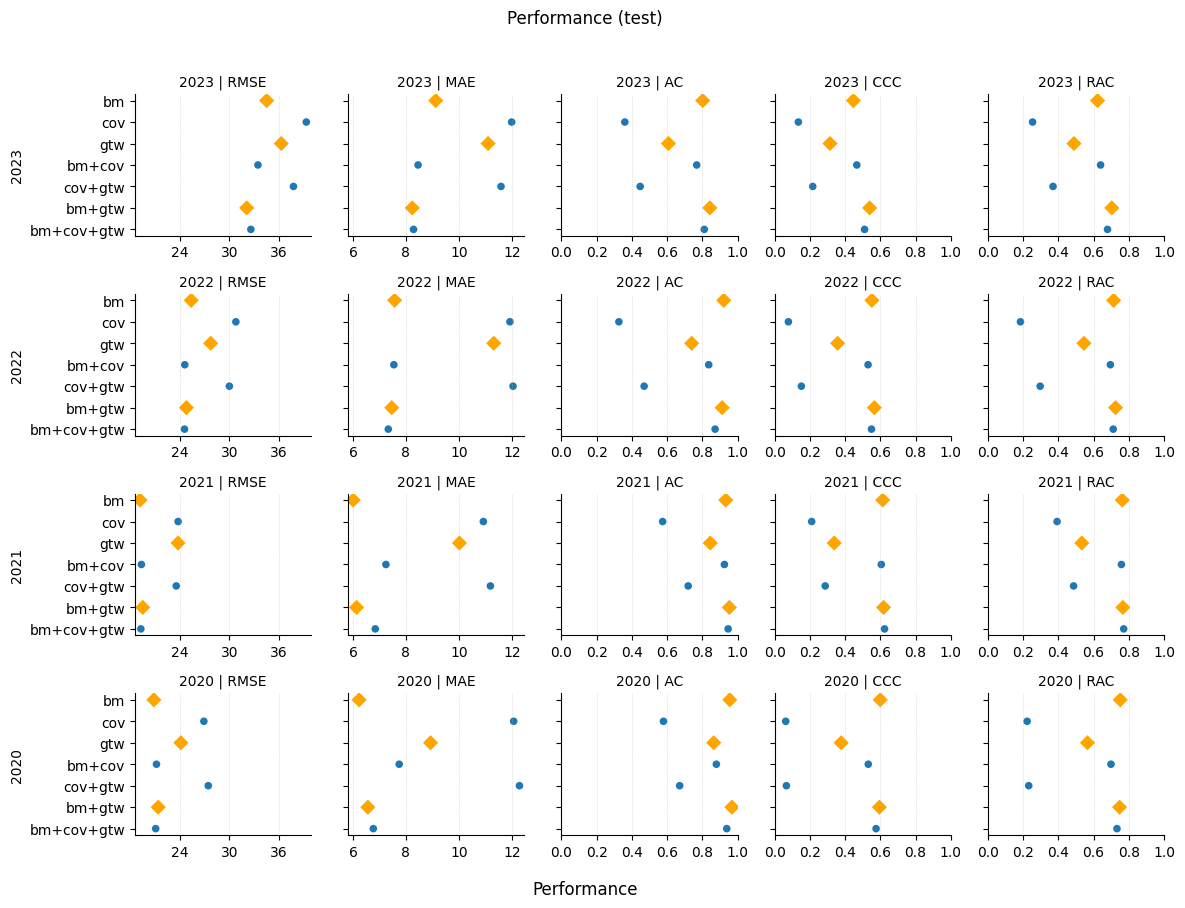

In [ ]:
# --- Example usage -----------------------------------------------------------
# 1) If your res_df already contains only TEST metrics for SRI:
res_df = pd.read_csv("results/admin0_africa_nsv.csv")
plot_metrics_panel(res_df, outcome=None, save_path="figures/admin0_africa_nsv.pdf")

## Country-level / Security-related / Africa

In [8]:
import os
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------
# 1) Configure where your data lives
# ----------------------------
DATA_PATH = "data/fulldata_adm0_africa.parquet"  # change to your file path

# ----------------------------
# 2) Helpers to load the original full data in Python
# ----------------------------
df = pd.read_parquet(DATA_PATH)

# Ensure expected columns exist
required_base = ["country_name","gwno","year","month","yearmonth","sri_num"]
missing_base = [c for c in required_base if c not in df.columns]
if missing_base:
    raise SystemExit(f"[!] Missing required columns: {missing_base}")

# ----------------------------
# 3) Define variable groups exactly like in your R code
# ----------------------------
# Outcomes (you can switch to sbv_fat_be, osv_fat_be, nsv_fat_be if desired)
TARGET = "sri_num"

# Benchmark (BM) predictors (lagged outcomes)
bm_vars = [
    "sbv_fat_be_lag", "osv_fat_be_lag", "nsv_fat_be_lag", "sri_num_lag", "sri_fat_lag"
]

# Covariate (COV) predictors (full set from your non-log script)
cov_vars = [
    "cinc", "elev_mean", "ethfrac", "ethpol", "farmland", "forest", "irregular",
    "irst", "milex", "milper", "n_leaders", "nbuiltup", "nethgr", "newlmtnest", "npetro",
    "open_terrain", "pec", "relfrac", "relpol", "road_density", "road_length", "rugged",
    "sum_igo_anytype", "sum_igo_associate", "sum_igo_full", "sum_igo_observer",
    "tpop", "upop", "v2x_polyarchy", "wbgdp2011est", "wbgdppc2011est", "wbpopest", "xm_qudsest",
    "l1_irregular", "l1_leadertransition", "l1_n_leaders", "l1_v2x_polyarchy",
    "l1_wbgdppc2011est", "l1_wbpopest", "l1_xm_qudsest"
]

# Google Trends + Wikipedia (GTW) predictors
gtw_vars = [c for c in df.columns if (c.startswith("views") or c.startswith("hits")) and not (c.endswith("log") or c.endswith("change"))]

# Filter to keep only existing columns (robust to minor name differences)
bm_vars = [c for c in bm_vars if c in df.columns]
cov_vars = [c for c in cov_vars if c in df.columns]
gtw_vars = [c for c in gtw_vars if c in df.columns]

# Safety check: drop rows with any NA in the modeling columns we’ll use in each run
id_cols = ["country_name","gwno","year","month","yearmonth"]

# ----------------------------
# 4) Metric functions (RMSE, MAE, AC, CCC, RAC)
# ----------------------------
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)

# Lin's concordance correlation coefficient (CCC)
def ccc(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    s_x2 = y_true.var(ddof=1)
    s_y2 = y_pred.var(ddof=1)
    s_xy = np.cov(y_true, y_pred, ddof=1)[0,1]
    return (2 * s_xy) / (s_x2 + s_y2 + (mu_x - mu_y)**2 + 1e-12)

# Accuracy coefficient (AC) = Lin's accuracy component C_b (so CCC = r * AC)
def accuracy_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    s_x = y_true.std(ddof=1)
    s_y = y_pred.std(ddof=1)
    mu_x = y_true.mean()
    mu_y = y_pred.mean()
    if s_x == 0 or s_y == 0:
        return 0.0
    v = (s_y / s_x) + (s_x / s_y) + ((mu_y - mu_x)**2) / (s_x * s_y)
    return 2.0 / (v + 1e-12)

# Robinson’s Agreement Coefficient (RAC).
# Here we use the widely adopted "Willmott-style" agreement denominator,
# which has been referred to as a Robinson/Agreement coefficient in forecasting work:
# RAC = 1 - sum((y - ŷ)^2) / sum((|ŷ - ȳ| + |y - ȳ|)^2)
def rac(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float)
    y_pred = np.asarray(y_pred).astype(float)
    ybar = y_true.mean()
    num = np.sum((y_true - y_pred)**2)
    den = np.sum((np.abs(y_pred - ybar) + np.abs(y_true - ybar))**2) + 1e-12
    return 1 - num / den

# ----------------------------
# 5) Modeling grids akin to your mtry sequences (clamped to the feature count)
# ----------------------------
def mtry_grid(n_features, base_seq):
    # clamp each candidate to [1, n_features]
    uniq = sorted({max(1, min(n_features, int(x))) for x in base_seq})
    # also include "sqrt" and "log2" styled choices via fractions if appropriate
    if n_features >= 3:
        uniq = sorted(set(uniq + [int(np.sqrt(n_features)), max(1,int(np.log2(n_features)))]) )
    return uniq

# Sequences ported from your R code
seqs = {
    "bm":       list(range(1,6)),                  # 1..5
    "cov":      list(range(5,41,5)),               # 5..40 step 5
    "gtw":      list(range(5,21,5)),               # 5..20
    "bm_gtw":   list(range(5,26,5)),               # 5..25
    "bm_cov":   list(range(5,46,5)),               # 5..45
    "cov_gtw":  list(range(5,61,5)),               # 5..60
    "bm_cov_gtw": list(range(5,66,5)),             # 5..65
}

def build_feature_sets():
    combos = {
        "bm": bm_vars,
        "cov": cov_vars,
        "gtw": gtw_vars,
        "bm_gtw": bm_vars + gtw_vars,
        "cov_gtw": cov_vars + gtw_vars,
        "bm_cov": bm_vars + cov_vars,
        "bm_cov_gtw": bm_vars + cov_vars + gtw_vars
    }
    # drop duplicates while preserving order
    for k,v in combos.items():
        seen, dedup = set(), []
        for col in v:
            if col not in seen:
                dedup.append(col); seen.add(col)
        combos[k] = dedup
    return combos

feature_sets = build_feature_sets()

# ----------------------------
# 6) Train/Test split + model selection + metrics for each year & model
# ----------------------------
YEARS = [2020, 2021, 2022, 2023]

results = []
predictions_by_run = {}  # optional: to let you inspect per-run preds later

for heldout_year in YEARS:
    print(f"Processing {heldout_year}")
    # Train: all <= heldout_year-1; Test: == heldout_year
    train_idx = df["year"] <= (heldout_year - 1)
    test_idx  = df["year"] == heldout_year

    df_train = df.loc[train_idx].copy()
    df_test  = df.loc[test_idx].copy()

    if df_test.empty or df_train.empty:
        print(f"[!] Skipping {heldout_year}: train or test is empty.")
        continue

    for model_name, cols in feature_sets.items():
        print(f"Processing {model_name}")
        if len(cols) == 0:
            print(f"[!] Skipping {model_name}: no matching feature columns in data.")
            continue

        # drop rows with any NA in target or features (no intermediate datasets saved)
        needed = cols + [TARGET]
        df_train_clean = df_train.dropna(subset=needed)
        df_test_clean  = df_test.dropna(subset=needed)

        if df_test_clean.empty or df_train_clean.empty:
            print(f"[!] {heldout_year} / {model_name}: no rows after dropping NAs, skipping.")
            continue

        X_train = df_train_clean[cols].values
        y_train = df_train_clean[TARGET].values
        X_test  = df_test_clean[cols].values
        y_test  = df_test_clean[TARGET].values

        # Build mtry (max_features) grid per model, clamped to feature count
        nfeat = X_train.shape[1]
        grid_mtry = mtry_grid(nfeat, seqs[model_name if model_name in seqs else "bm"])

        # Define RF; tune only max_features & min_samples_leaf (analogous to min.node.size)
        param_grid = {
            "max_features": grid_mtry,
            "min_samples_leaf": [5, 10],   # mirrors your 5 & 10
            "max_depth": [None],           # keep trees deep; RF handles overfit via averaging
        }

        base = RandomForestRegressor(
            n_estimators=1000,
            n_jobs=-1,
            random_state=815,
            bootstrap=True
        )

        # 3-fold CV on the training set (shuffled=False to respect time-ish ordering)
        cv = KFold(n_splits=3, shuffle=False)
        gs = GridSearchCV(base, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=1)
        gs.fit(X_train, y_train)

        best_model = gs.best_estimator_
        y_pred = best_model.predict(X_test)

        # Metrics
        metric_rmse = rmse(y_test, y_pred)
        metric_mae  = mae(y_test, y_pred)
        metric_ccc  = ccc(y_test, y_pred)
        metric_ac   = accuracy_coefficient(y_test, y_pred)
        metric_rac  = rac(y_test, y_pred)

        res = {
            "heldout_year": heldout_year,
            "model": model_name,
            "n_features": nfeat,
            "best_max_features": best_model.get_params().get("max_features"),
            "best_min_samples_leaf": best_model.get_params().get("min_samples_leaf"),
            "RMSE": metric_rmse,
            "MAE": metric_mae,
            "AC": metric_ac,
            "CCC": metric_ccc,
            "RAC": metric_rac
        }
        results.append(res)
        print(res)

        # stash predictions (optional)
        key = (heldout_year, model_name)
        predictions_by_run[key] = pd.DataFrame({
            "country_name": df_test_clean["country_name"].values if "country_name" in df_test_clean.columns else np.nan,
            "gwno": df_test_clean["gwno"].values if "gwno" in df_test_clean.columns else np.nan,
            "year": df_test_clean["year"].values,
            "month": df_test_clean["month"].values if "month" in df_test_clean.columns else np.nan,
            "yearmonth": df_test_clean["yearmonth"].values if "yearmonth" in df_test_clean.columns else np.nan,
            "y_true": y_test,
            "y_pred": y_pred
        })

# Aggregate results into a tidy table
res_df = pd.DataFrame(results)
res_df.to_csv("results/admin0_africa_nsv.csv")

# Order columns nicely
cols_order = ["heldout_year","model","n_features","best_max_features","best_min_samples_leaf",
                "RMSE","MAE","AC","CCC","RAC"]
res_df = res_df[cols_order].sort_values(["heldout_year","model"]).reset_index(drop=True)

# Show a compact summary (rounded)
display_df = res_df.copy()
for m in ["RMSE","MAE","AC","CCC","RAC"]:
    display_df[m] = display_df[m].astype(float).round(4)

# Print the first few rows here for quick glance
display_df

Processing 2020
Processing bm
Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'heldout_year': 2020, 'model': 'bm', 'n_features': 5, 'best_max_features': 3, 'best_min_samples_leaf': 10, 'RMSE': 20.33379811205533, 'MAE': 8.005327419589884, 'AC': 0.983772596536274, 'CCC': 0.9267059164929653, 'RAC': 0.9620714449920009}
Processing cov
Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'heldout_year': 2020, 'model': 'cov', 'n_features': 40, 'best_max_features': 15, 'best_min_samples_leaf': 10, 'RMSE': 59.564771023520024, 'MAE': 28.918174672059607, 'AC': 0.5007232730144817, 'CCC': 0.06436582558228396, 'RAC': 0.3165413627605761}
Processing gtw
Fitting 3 folds for each of 10 candidates, totalling 30 fits
{'heldout_year': 2020, 'model': 'gtw', 'n_features': 21, 'best_max_features': 10, 'best_min_samples_leaf': 5, 'RMSE': 37.18477667860919, 'MAE': 18.199252329943203, 'AC': 0.8441031592689732, 'CCC': 0.6889743559383547, 'RAC': 0.8194118800558399}
Processing bm_gtw
Fitting 

,heldout_year,model,n_features,best_max_features,best_min_samples_leaf,RMSE,MAE,AC,CCC,RAC
0,2020,bm,5,3,10,20.3338,8.0053,0.9838,0.9267,0.9621
1,2020,bm_cov,45,15,5,33.7736,13.2222,0.8142,0.7346,0.8476
2,2020,bm_cov_gtw,66,25,5,31.4233,12.2534,0.8504,0.7773,0.8751
3,2020,bm_gtw,26,15,5,22.5419,8.8687,0.9695,0.9053,0.9504
4,2020,cov,40,15,10,59.5648,28.9182,0.5007,0.0644,0.3165
5,2020,cov_gtw,61,35,5,60.7728,30.1487,0.5425,0.0366,0.3012
6,2020,gtw,21,10,5,37.1848,18.1993,0.8441,0.6890,0.8194
7,2021,bm,5,3,10,21.2840,8.8655,0.9829,0.9390,0.9686
8,2021,bm_cov,45,15,5,29.8905,11.7332,0.9143,0.8586,0.9240
9,2021,bm_cov_gtw,66,20,5,28.7642,11.3795,0.9258,0.8712,0.9312


Saved: figures/admin0_africa_sri.pdf


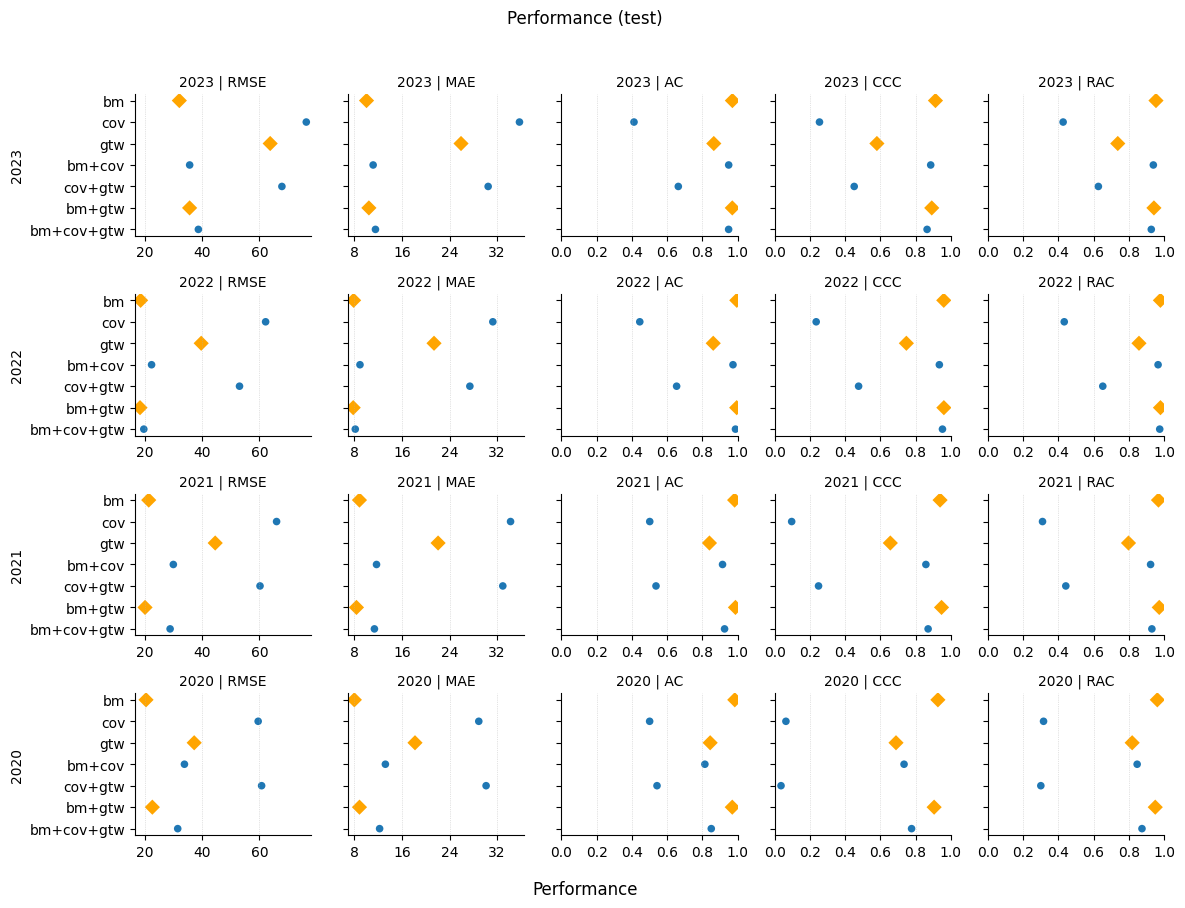

In [2]:
res_df = pd.read_csv("results/admin0_africa_sri.csv")
plot_metrics_panel(res_df, outcome=None, save_path="figures/admin0_africa_sri.pdf")

/scratch/local/jobs/39757111/ipykernel_1316038/68587961.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({"MAE": mae(d["y_true"], d["y_pred"])}))
/scratch/local/jobs/39757111/ipykernel_1316038/68587961.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({"MAE": mae(d["y_true"], d["y_pred"])}))
/scratch/local/jobs/39757111/ipykernel_1316038/68587961.

Saved:
  figures/adm0_africa_mae_map_2022.png
  figures/adm0_africa_mae_map_2022.pdf


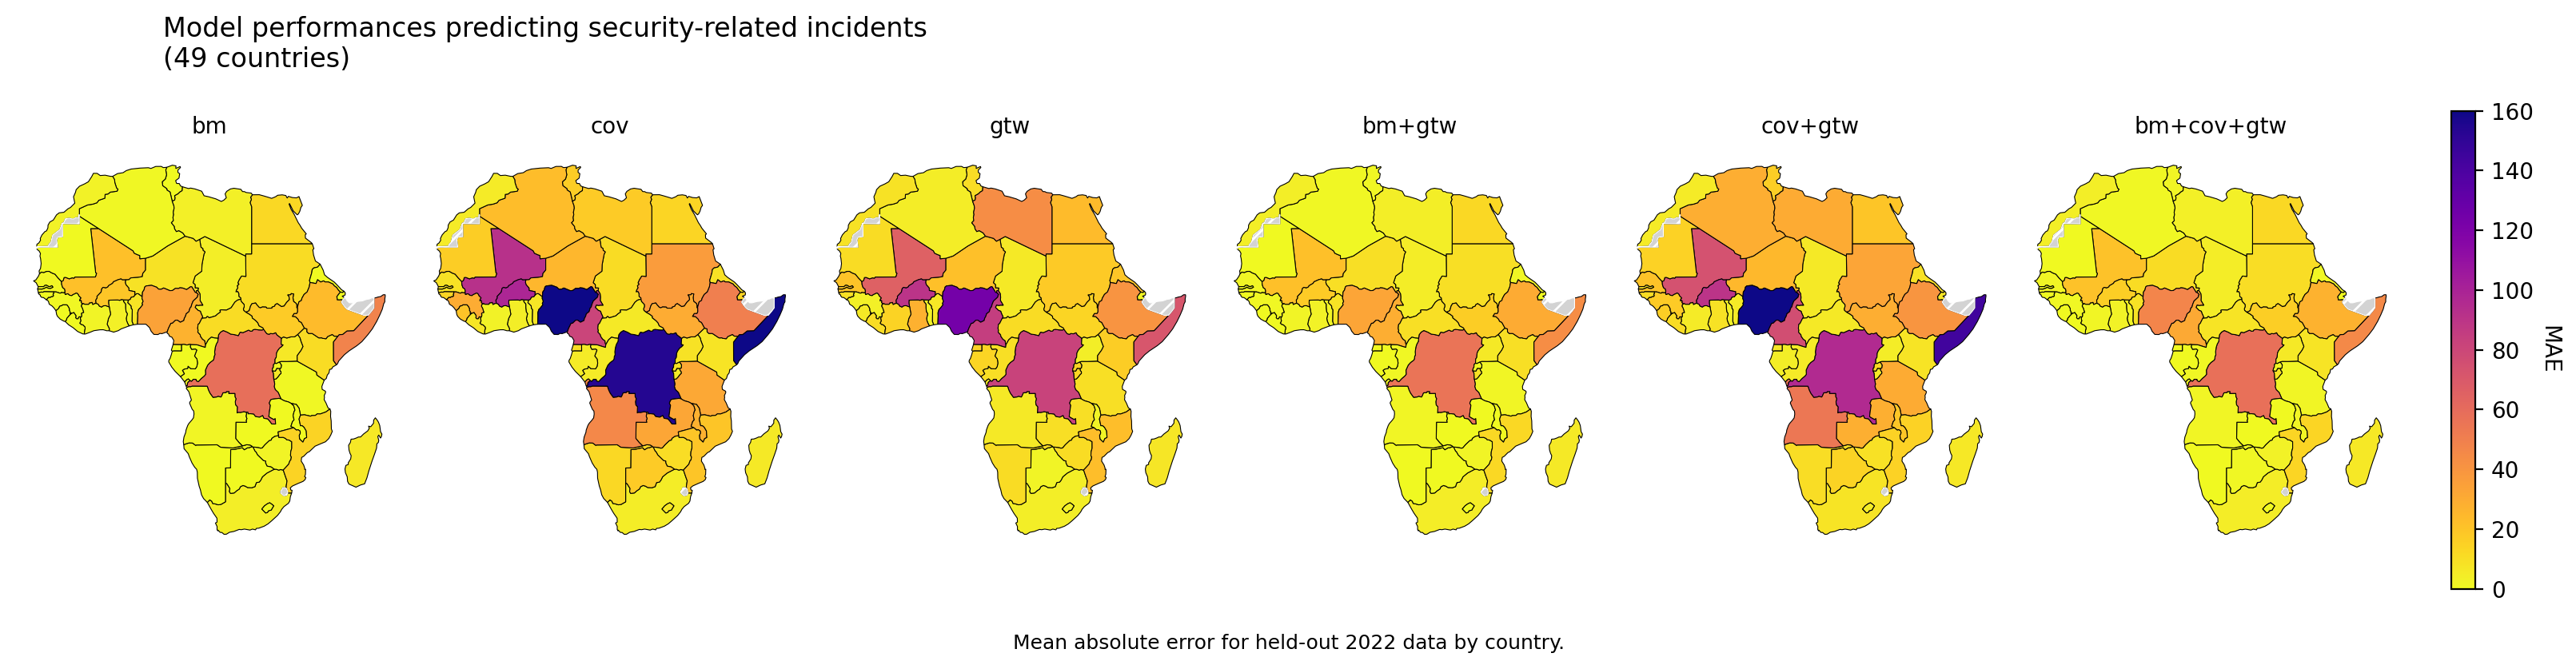

In [13]:
# === Figure 4 replica: Out-of-sample MAE by country, Africa (held-out year) ===
# Requires: predictions_by_run[(heldout_year, model_key)] -> DataFrame with:
#   ['country_name','y_true','y_pred', ...]
# Produces: figures/adm0_africa_mae_map_<heldout_year>.png (and .pdf)

import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

# -------------------------------------------------------------
# 0) Config
# -------------------------------------------------------------
HELDOUT_YEAR = 2022
MODEL_ORDER = ["bm", "cov", "gtw", "bm_gtw", "cov_gtw", "bm_cov_gtw"]
MODEL_LABELS = {
    "bm": "bm",
    "cov": "cov",
    "gtw": "gtw",
    "bm_gtw": "bm+gtw",
    "cov_gtw": "cov+gtw",
    "bm_cov_gtw": "bm+cov+gtw",
}
OUTDIR = "figures"
os.makedirs(OUTDIR, exist_ok=True)

# -------------------------------------------------------------
# 1) Bring in predictions (adapt if you read from files)
# -------------------------------------------------------------
def collect_predictions():
    """
    Returns a dict keyed by (HELDOUT_YEAR, model_key) → DataFrame
    with columns 'country_name', 'y_true', 'y_pred'.
    Here we assume your training loop already created `predictions_by_run`.
    """
    # If your predictions live elsewhere, load and reshape here to match:
    # return {(2022, "bm"): df_bm_2022, ...}
    return predictions_by_run

pred_by_run = collect_predictions()

# -------------------------------------------------------------
# 2) Compute per-country MAE for each model (held-out year)
# -------------------------------------------------------------
def mae(y_true, y_pred):  # same as in your pipeline
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

rows = []
for m in MODEL_ORDER:
    key = (HELDOUT_YEAR, m)
    if key not in pred_by_run:
        print(f"[warn] Missing predictions for {key}; skipping.")
        continue
    dfp = pred_by_run[key].copy()
    if "country_name" not in dfp.columns:
        raise ValueError(f"{key} has no 'country_name' column.")
    # group to country-level MAE
    g = (dfp
         .dropna(subset=["country_name","y_true","y_pred"])
         .groupby("country_name", as_index=False)
         .apply(lambda d: pd.Series({"MAE": mae(d["y_true"], d["y_pred"])}))
         .reset_index(drop=True))
    g["model"] = m
    rows.append(g)

if not rows:
    raise SystemExit("No MAE rows were produced; check predictions_by_run contents.")
mae_by_cty = pd.concat(rows, ignore_index=True)

# -------------------------------------------------------------
# 3) Harmonize names to Natural Earth and join geometries
# -------------------------------------------------------------
import geopandas as gpd
afr = gpd.read_file("data/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
afr = afr[afr["CONTINENT"].eq("Africa")].copy()
afr = afr[["NAME_EN", "geometry"]].rename(columns={"NAME_EN": "ne_name"})

# Natural Earth country name column is 'name'
# Map common mismatches from your data's 'country_name' to NE 'name'
NAME_FIX = {
    "Cote d'Ivoire": "Ivory Coast",
    "Congo, Dem. Rep.": "Democratic Republic of the Congo",
    "Congo, Rep.": "Republic of the Congo",
    "Gambia, The": "Gambia",
    "Eswatini": "eSwatini",        # NE uses 'eSwatini' in some versions
    "Cabo Verde": "Cape Verde",
    "Somaliland": "Somalia",       # not in NE; map to Somalia
    "South Sudan": "South Sudan",  # included, but keep explicit
    "Sao Tome and Principe": "São Tomé and Príncipe",
}
def std_name(x):
    return NAME_FIX.get(x, x)

mae_by_cty["ne_name"] = mae_by_cty["country_name"].map(std_name)

# -------------------------------------------------------------
# 4) Build one GeoDataFrame per model + global color scale
# -------------------------------------------------------------
model_geos = []
for m in MODEL_ORDER:
    mm = mae_by_cty[mae_by_cty["model"].eq(m)]
    gdf = afr.merge(mm[["ne_name","MAE"]], on="ne_name", how="left")
    gdf["model"] = m
    model_geos.append(gdf)

# Common color scale across all panels
all_mae_vals = pd.concat([g[["MAE"]] for g in model_geos], ignore_index=True)["MAE"]
vmin = 0.0
# Choose vmax either from data or clamp to a target (e.g., 250 like the paper)
vmax_data = float(np.nanpercentile(all_mae_vals, 99)) if not all_mae_vals.dropna().empty else 1.0
vmax = max(50.0, min(250.0, round(vmax_data/10)*10))   # modest heuristic to keep legend readable

norm = Normalize(vmin=vmin, vmax=vmax, clip=True)
cmap = get_cmap("plasma_r")  # similar to the figure’s yellow→purple

# -------------------------------------------------------------
# 5) Plot: 1×6 panels, shared colorbar
# -------------------------------------------------------------
fig, axes = plt.subplots(
    1, len(MODEL_ORDER),
    figsize=(16, 3.6),
    dpi=200,
    constrained_layout=True
)

for ax, m, gdf in zip(axes, MODEL_ORDER, model_geos):
    gdf.plot(ax=ax, column="MAE", cmap=cmap, norm=norm, linewidth=0.4, edgecolor="black", missing_kwds={
        "color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"
    })
    ax.set_title(MODEL_LABELS[m], fontsize=10, pad=6)
    ax.axis("off")

# Title and subtitle (left aligned)
fig.suptitle("Model performances predicting security-related incidents\n(49 countries)", x=0.06, y=1.08, ha="left", fontsize=12)

# Single colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label("MAE", rotation=270, labelpad=12)

# Footnote
fig.text(0.5, -0.02, f"Mean absolute error for held-out {HELDOUT_YEAR} data by country.", ha="center", fontsize=9)

# Save
png_path = os.path.join(OUTDIR, f"adm0_africa_mae_map_{HELDOUT_YEAR}.png")
pdf_path = os.path.join(OUTDIR, f"adm0_africa_mae_map_{HELDOUT_YEAR}.pdf")
fig.savefig(png_path, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
print(f"Saved:\n  {png_path}\n  {pdf_path}")


## Province-level / Non-state Violence / Africa

In [ ]:
# ===== ADM1 Africa: Faster RF forecasting (random CV, 250 trees for CV, retrain with 1000) =====
# No intermediate datasets—everything is sliced straight from the full source table.

import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ----------------------------------------------------------------------------------------
# 0) CONFIG
# ----------------------------------------------------------------------------------------
DATA_PATH = Path("data/fulldata_adm1_africa.parquet")   # change to your file
TARGET = "nsv_fat_be"                                    # 'sri_num', 'nsv_fat_be', 'sbv_fat_be', 'osv_fat_be'
YEARS  = [2020, 2021, 2022, 2023]

# How many random param draws to try during CV
N_RANDOM_TRIALS = 12     # speed knob: smaller = faster
CV_N_SPLITS     = 3
CV_TREES        = 500     # use fewer trees during CV
FINAL_TREES     = 1000    # retrain winner with this many trees

RANDOM_STATE    = 815

# ----------------------------------------------------------------------------------------
# 1) Load full ADM1 data
# ----------------------------------------------------------------------------------------
df = pd.read_parquet(DATA_PATH).copy()

needed = ["gadmname", "isocode2full", "year", "month"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise SystemExit(f"Missing required ADM1 columns: {missing}")

if TARGET not in df.columns:
    raise SystemExit(f"Target column '{TARGET}' not found.")

# ----------------------------------------------------------------------------------------
# 2) Feature groups (mirrors your ADM1 R script)
# ----------------------------------------------------------------------------------------
bm_vars = ["sbv_fat_be_lag", "osv_fat_be_lag", "nsv_fat_be_lag", "sri_num_lag", "sri_fat_lag"]

cov_vars = [
    "elev_mean", "farmland", "forest", "gdp_ppp", "nbuiltup", "nethgr", "nl", "npetro",
    "open_terrain", "pop_sum", "rain", "road_density", "road_length", "temp"
]

gtw_vars = [c for c in df.columns
            if (c.startswith("views") or c.startswith("hits"))
            and not (c.endswith("log") or c.endswith("change"))]

bm_vars  = [c for c in bm_vars  if c in df.columns]
cov_vars = [c for c in cov_vars if c in df.columns]
gtw_vars = [c for c in gtw_vars if c in df.columns]

def build_feature_sets():
    combos = {
        "bm": bm_vars,
        "cov": cov_vars,
        "gtw": gtw_vars,
        "bm_gtw": bm_vars + gtw_vars,
        "cov_gtw": cov_vars + gtw_vars,
        "bm_cov": bm_vars + cov_vars,
        "bm_cov_gtw": bm_vars + cov_vars + gtw_vars,
    }
    out = {}
    for k, cols in combos.items():
        seen, dedup = set(), []
        for c in cols:
            if c not in seen:
                dedup.append(c); seen.add(c)
        out[k] = dedup
    return out

FEATURE_SETS = build_feature_sets()

# ----------------------------------------------------------------------------------------
# 3) Metrics
# ----------------------------------------------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

def ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    mu_x, mu_y = y_true.mean(), y_pred.mean()
    s_x2, s_y2 = y_true.var(ddof=1), y_pred.var(ddof=1)
    s_xy = np.cov(y_true, y_pred, ddof=1)[0, 1]
    return float((2 * s_xy) / (s_x2 + s_y2 + (mu_x - mu_y) ** 2 + 1e-12))

def accuracy_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    s_x, s_y = y_true.std(ddof=1), y_pred.std(ddof=1)
    mu_x, mu_y = y_true.mean(), y_pred.mean()
    if s_x == 0 or s_y == 0:
        return 0.0
    v = (s_y / s_x) + (s_x / s_y) + ((mu_y - mu_x) ** 2) / (s_x * s_y)
    return float(2.0 / (v + 1e-12))

def rac(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float); y_pred = np.asarray(y_pred, dtype=float)
    ybar = y_true.mean()
    num = np.sum((y_true - y_pred) ** 2)
    den = np.sum((np.abs(y_pred - ybar) + np.abs(y_true - ybar)) ** 2) + 1e-12
    return float(1 - num / den)

# ----------------------------------------------------------------------------------------
# 4) mtry sequences (ADM1, like your R)
# ----------------------------------------------------------------------------------------
ADM1_MTRY_SEQ = {
    "bm":          list(range(1, 6)),            # 1..5
    "cov":         list(range(2, 15, 2)),        # 2..14 step 2
    "gtw":         list(range(5, 21, 5)),        # 5..20
    "bm_gtw":      list(range(5, 26, 5)),        # 5..25
    "bm_cov":      list(range(5, 21, 5)),        # 5..20
    "cov_gtw":     list(range(5, 36, 5)),        # 5..35
    "bm_cov_gtw":  list(range(5, 41, 5)),        # 5..40
}

def mtry_grid(n_features: int, model_key: str):
    base = ADM1_MTRY_SEQ.get(model_key, [1, 2, 3, 4, 5])
    clamped = sorted({max(1, min(n_features, int(x))) for x in base})
    if n_features >= 3:
        clamped.extend([int(np.sqrt(n_features)), max(1, int(np.log2(n_features)))])
    return sorted(set(clamped))

# ----------------------------------------------------------------------------------------
# 5) Fit/Eval with RandomizedSearchCV (250 trees), then refit-best with 1000 trees
# ----------------------------------------------------------------------------------------
def fit_eval_year(df_full: pd.DataFrame, heldout_year: int, model_key: str, features: list):
    # Train ≤ (year-1); Test == year
    df_tr = df_full[df_full["year"] <= (heldout_year - 1)]
    df_te = df_full[df_full["year"] == heldout_year]
    if df_tr.empty or df_te.empty:
        return None

    cols_needed = features + [TARGET]
    df_tr = df_tr.dropna(subset=cols_needed)
    df_te = df_te.dropna(subset=cols_needed)
    if df_tr.empty or df_te.empty:
        return None

    X_tr = df_tr[features].to_numpy()
    y_tr = df_tr[TARGET].to_numpy()
    X_te = df_te[features].to_numpy()
    y_te = df_te[TARGET].to_numpy()

    nfeat = X_tr.shape[1]
    # param "distributions" (sampled randomly)
    mtry_choices = mtry_grid(nfeat, model_key)
    param_dist = {
        "max_features": mtry_choices,    # discrete choices
        "min_samples_leaf": [5, 10]
    }

    base_cv_model = RandomForestRegressor(
        n_estimators=CV_TREES,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    # Keep time order (no shuffle) but sample params at random
    cv = KFold(n_splits=CV_N_SPLITS, shuffle=False)

    rs = RandomizedSearchCV(
        estimator=base_cv_model,
        param_distributions=param_dist,
        n_iter=min(N_RANDOM_TRIALS, len(mtry_choices) * 2),  # cap trials
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        cv=cv,
        random_state=RANDOM_STATE,
        verbose=1
    )
    rs.fit(X_tr, y_tr)
    best_params = rs.best_params_

    # Retrain winner with 1000 trees on full train
    final_model = RandomForestRegressor(
        n_estimators=FINAL_TREES,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_features=best_params["max_features"],
        min_samples_leaf=best_params["min_samples_leaf"]
    )
    final_model.fit(X_tr, y_tr)
    y_hat = final_model.predict(X_te)

    return {
        "heldout_year": heldout_year,
        "model": model_key,
        "n_features": nfeat,
        "best_max_features": best_params["max_features"],
        "best_min_samples_leaf": best_params["min_samples_leaf"],
        "RMSE": rmse(y_te, y_hat),
        "MAE": mae(y_te, y_hat),
        "AC": accuracy_coefficient(y_te, y_hat),
        "CCC": ccc(y_te, y_hat),
        "RAC": rac(y_te, y_hat),
    }

# ----------------------------------------------------------------------------------------
# 6) Run all held-out years × model variants
# ----------------------------------------------------------------------------------------
all_results = []
for yr in YEARS:
    print(f"Processing {yr}")
    for mkey, feats in FEATURE_SETS.items():
        if not feats:
            continue
        print(f"  - {mkey}")
        res = fit_eval_year(df, yr, mkey, feats)
        if res is not None:
            all_results.append(res)

results_df = pd.DataFrame(all_results)
if results_df.empty:
    print("No results produced—check data availability, NA filtering, and TARGET column.")
else:
    cols = ["heldout_year","model","n_features","best_max_features","best_min_samples_leaf",
            "RMSE","MAE","AC","CCC","RAC"]
    results_df = results_df[cols].sort_values(["heldout_year","model"]).reset_index(drop=True)

res_df = results_df
res_df.to_csv("results/admin1_africa_nsv.csv")
res_df

Processing 2020
  - bm
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  - cov
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  - gtw
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  - bm_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  - cov_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  - bm_cov
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  - bm_cov_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Processing 2021
  - bm
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  - cov
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  - gtw
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  - bm_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  - cov_gtw
Fitting 3 folds for each of 12 candidates, totalling 36 fits
  - bm_cov
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  - bm_cov_gtw
Fitting 3 folds for each of 12 

,heldout_year,model,n_features,best_max_features,best_min_samples_leaf,RMSE,MAE,AC,CCC,RAC
0,2020,bm,5,2,10,5.123470,0.535135,0.863384,0.395197,0.567531
1,2020,bm_cov,19,5,5,5.123337,0.494291,0.864269,0.395581,0.568091
2,2020,bm_cov_gtw,40,10,5,5.078634,0.515226,0.834410,0.387138,0.559472
3,2020,bm_gtw,26,5,5,5.092002,0.534804,0.781642,0.355016,0.525465
4,2020,cov,14,2,10,5.709738,0.683895,0.542956,0.080751,0.159286
5,2020,cov_gtw,35,5,10,5.621855,0.773735,0.516874,0.101251,0.193419
6,2020,gtw,21,5,10,5.701805,0.815064,0.227219,0.016641,0.043831
7,2021,bm,5,2,10,4.232399,0.475113,0.880983,0.508243,0.674415
8,2021,bm_cov,19,5,5,4.367978,0.455633,0.844763,0.453982,0.625209
9,2021,bm_cov_gtw,40,10,5,4.356251,0.486305,0.845258,0.457313,0.628490


Saved: figures/admin1_africa_nsv.pdf


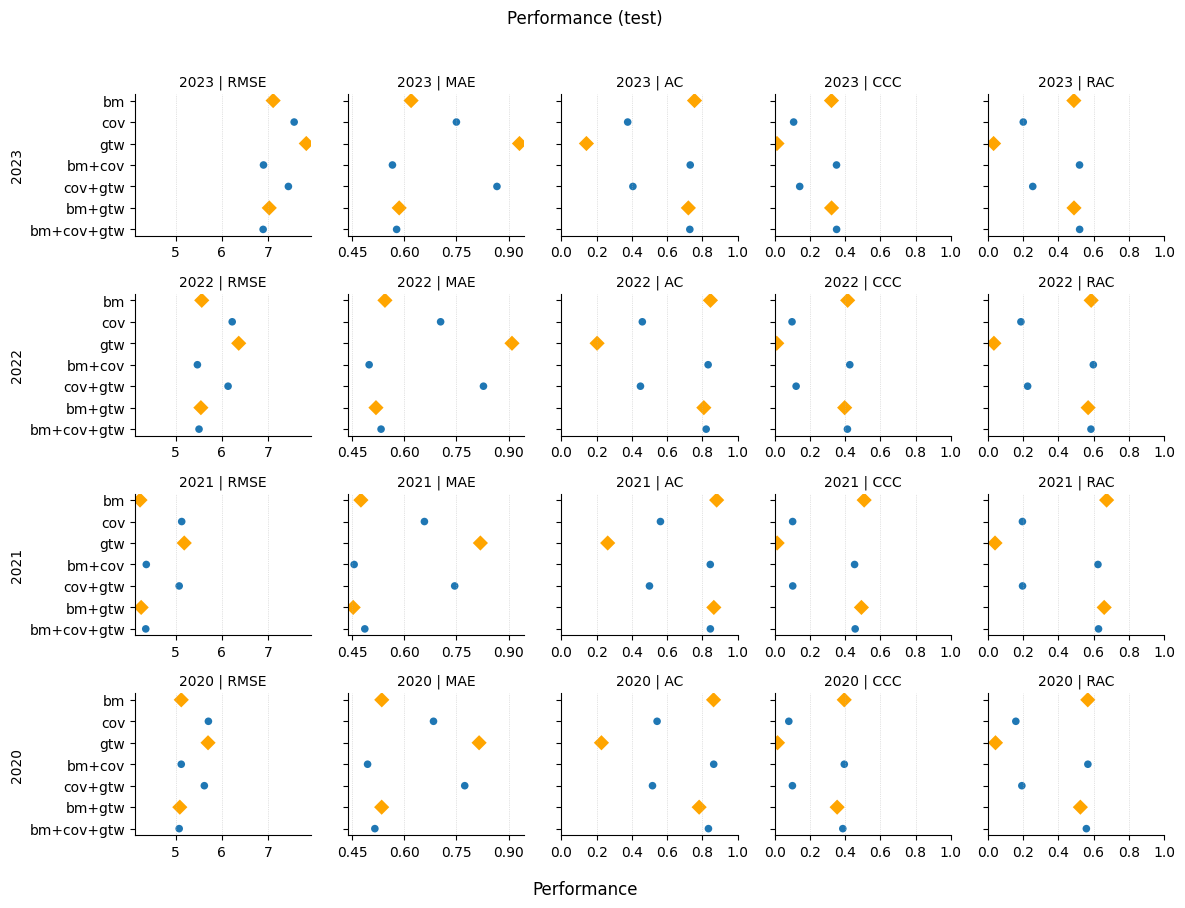

In [5]:
plot_metrics_panel(res_df, outcome=None, save_path="figures/admin1_africa_nsv.pdf")